# Segmentation Client (K-means / PCA) & Profilage des segments


**Méthodologie suivie :**
0. Importation de dependance
1. Chargement des données brutes (3 tables séparées, comme dans le vrai projet)
2. Audit qualité rapide
3. Feature engineering (RFM : Récence, Fréquence, Montant)
4. Vérification de cohérence : `Total_Spent` vs `Monetary_Total`
5. EDA
6. Prétraitement (standardisation)
7. Réduction de dimension (PCA)
8. Choix du nombre optimal de clusters (coude + silhouette)
9. Application du K-means
10. Validation et interprétation
11. Profilage métier (personas) — M4
12. Export des résultats pour l'équipe


## 0. Imports et configuration

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## 1. Chargement de données

In [20]:
df= pd.read_csv("../data/processed/dataset_data_final.csv")
print("Dimensions :", df.shape)
print("\nColonnes :", df.columns.tolist())
df.head()


df.head()


Dimensions : (5, 18)

Colonnes : ['Sale_ID', 'Product_ID', 'Customer_ID', 'Date', 'Quantity', 'Sale_Price', 'Channel', 'Product_Name', 'Category', 'Price', 'Brand', 'Name', 'Age', 'Gender', 'Location', 'Join_Date', 'Total_Spent', 'Revenue']


,Sale_ID,Product_ID,Customer_ID,Date,Quantity,Sale_Price,Channel,Product_Name,Category,Price,Brand,Name,Age,Gender,Location,Join_Date,Total_Spent,Revenue
0,1,101,2001,2023-01-15,2,50.0,Online,T-shirt,Clothing,25.0,Brand A,Alice,28,Female,New York,2022-05-10,500.0,100.0
1,2,102,2002,2023-01-16,1,75.0,In-Store,Jeans,Clothing,75.0,Brand B,Bob,35,Male,Los Angeles,2022-06-15,750.0,75.0
2,3,103,2001,2023-01-17,3,30.0,Online,Sneakers,Footwear,30.0,Brand C,Alice,28,Female,New York,2022-05-10,500.0,90.0
3,4,104,2003,2023-01-18,1,120.0,In-Store,Jacket,Outerwear,120.0,Brand D,Charlie,22,Male,Chicago,2022-07-20,300.0,120.0
4,5,105,2004,2023-01-19,2,45.0,Online,Hat,Accessories,22.5,Brand E,Diana,30,Female,Houston,2022-08-25,600.0,90.0


## 2. Audit qualité rapide

Réflexe systématique avant toute agrégation : valeurs manquantes, doublons, types.

In [21]:
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())
print("\nDoublons (lignes de transaction identiques) :", df.duplicated().sum())

df = df.drop_duplicates()
df["Date"] = pd.to_datetime(df["Date"])
df["Join_Date"] = pd.to_datetime(df["Join_Date"])
print("Après nettoyage :", df.shape)

Valeurs manquantes par colonne :
Sale_ID         0
Product_ID      0
Customer_ID     0
Date            0
Quantity        0
Sale_Price      0
Channel         0
Product_Name    0
Category        0
Price           0
Brand           0
Name            0
Age             0
Gender          0
Location        0
Join_Date       0
Total_Spent     0
Revenue         0
dtype: int64

Doublons (lignes de transaction identiques) : 0
Après nettoyage : (5, 18)


## 3. Feature engineering — variables RFM

Le dataset est au niveau **transaction** (une ligne = un achat). Le clustering doit se faire au
niveau **client** : il faut donc agréger. On construit ici une approche RFM enrichie :

| Catégorie | Variables | Rôle |
|---|---|---|
| RFM (cœur du clustering) | `recency_days`, `purchase_frequency`, `monetary_total` | Base de toute segmentation client |
| Valeur du panier | `avg_basket_value`, `total_quantity`, `avg_quantity_per_purchase` | Affine le comportement d'achat |
| Diversité produit | `nb_distinct_categories` | Client mono-catégorie vs généraliste |
| Ancienneté | `tenure_days` | Client récent vs fidèle depuis longtemps |
| Préférences (profilage M4, pas clustering direct) | `favorite_category`, `favorite_brand`, `preferred_channel` | Catégoriel — utile pour décrire les personas, pas pour le K-means brut |


In [22]:
reference_date = df["Date"].max() + pd.Timedelta(days=1)

customer_features = df.groupby("Customer_ID").agg(
    Name=("Name", "first"),
    Age=("Age", "first"),
    Gender=("Gender", "first"),
    Location=("Location", "first"),
    Join_Date=("Join_Date", "first"),
    Total_Spent=("Total_Spent", "first"),
    last_purchase_date=("Date", "max"),
    purchase_frequency=("Sale_ID", "nunique"),
    monetary_total=("Revenue", "sum"),
    total_quantity=("Quantity", "sum"),
    favorite_category=("Category", lambda x: x.mode()[0]),
    favorite_brand=("Brand", lambda x: x.mode()[0]),
    preferred_channel=("Channel", lambda x: x.mode()[0]),
    nb_distinct_categories=("Category", "nunique"),
).reset_index()

customer_features["recency_days"] = (reference_date - customer_features["last_purchase_date"]).dt.days
customer_features["avg_basket_value"] = (customer_features["monetary_total"] / customer_features["purchase_frequency"]).round(2)
customer_features["avg_quantity_per_purchase"] = (customer_features["total_quantity"] / customer_features["purchase_frequency"]).round(2)
customer_features["tenure_days"] = (reference_date - customer_features["Join_Date"]).dt.days

print("Dataset agrégé par client :", customer_features.shape)
customer_features.head()



Dataset agrégé par client : (4, 19)


,Customer_ID,Name,Age,Gender,Location,Join_Date,Total_Spent,last_purchase_date,purchase_frequency,monetary_total,total_quantity,favorite_category,favorite_brand,preferred_channel,nb_distinct_categories,recency_days,avg_basket_value,avg_quantity_per_purchase,tenure_days
0,2001,Alice,28,Female,New York,2022-05-10,500.0,2023-01-17,2,190.0,5,Clothing,Brand A,Online,2,3,95.0,2.5,255
1,2002,Bob,35,Male,Los Angeles,2022-06-15,750.0,2023-01-16,1,75.0,1,Clothing,Brand B,In-Store,1,4,75.0,1.0,219
2,2003,Charlie,22,Male,Chicago,2022-07-20,300.0,2023-01-18,1,120.0,1,Outerwear,Brand D,In-Store,1,2,120.0,1.0,184
3,2004,Diana,30,Female,Houston,2022-08-25,600.0,2023-01-19,1,90.0,2,Accessories,Brand E,Online,1,1,90.0,2.0,148


## 4. Vérification de cohérence : `Total_Spent` déclaré vs `monetary_total` recalculé

`Total_Spent` vient de `customers_data`, `monetary_total` est recalculé
directement depuis les vraies transactions (`Revenue`). Un écart important peut signaler un
problème de données (retours produits non pris en compte, erreur de saisie, etc.) - à creuser
avec la Data Engineer si l'écart est significatif sur les vraies données.


**Décision :** on utilise `monetary_total` pour le clustering (recalculé depuis les vraies
transactions, donc plus fiable que la valeur déclarée) plutôt que `Total_Spent`.

In [23]:
customer_features["ecart_total_spent"] = (
    customer_features["Total_Spent"] - customer_features["monetary_total"]
).abs()

print("Écart moyen :", customer_features["ecart_total_spent"].mean().round(2))
customer_features.sort_values("ecart_total_spent", ascending=False).head(10)[
    ["Customer_ID", 
     "Total_Spent", 
     "monetary_total", 
     "ecart_total_spent"
     ]
]


Écart moyen : 418.75


,Customer_ID,Total_Spent,monetary_total,ecart_total_spent
1,2002,750.0,75.0,675.0
3,2004,600.0,90.0,510.0
0,2001,500.0,190.0,310.0
2,2003,300.0,120.0,180.0


## 5. Analyse exploratoire (EDA)

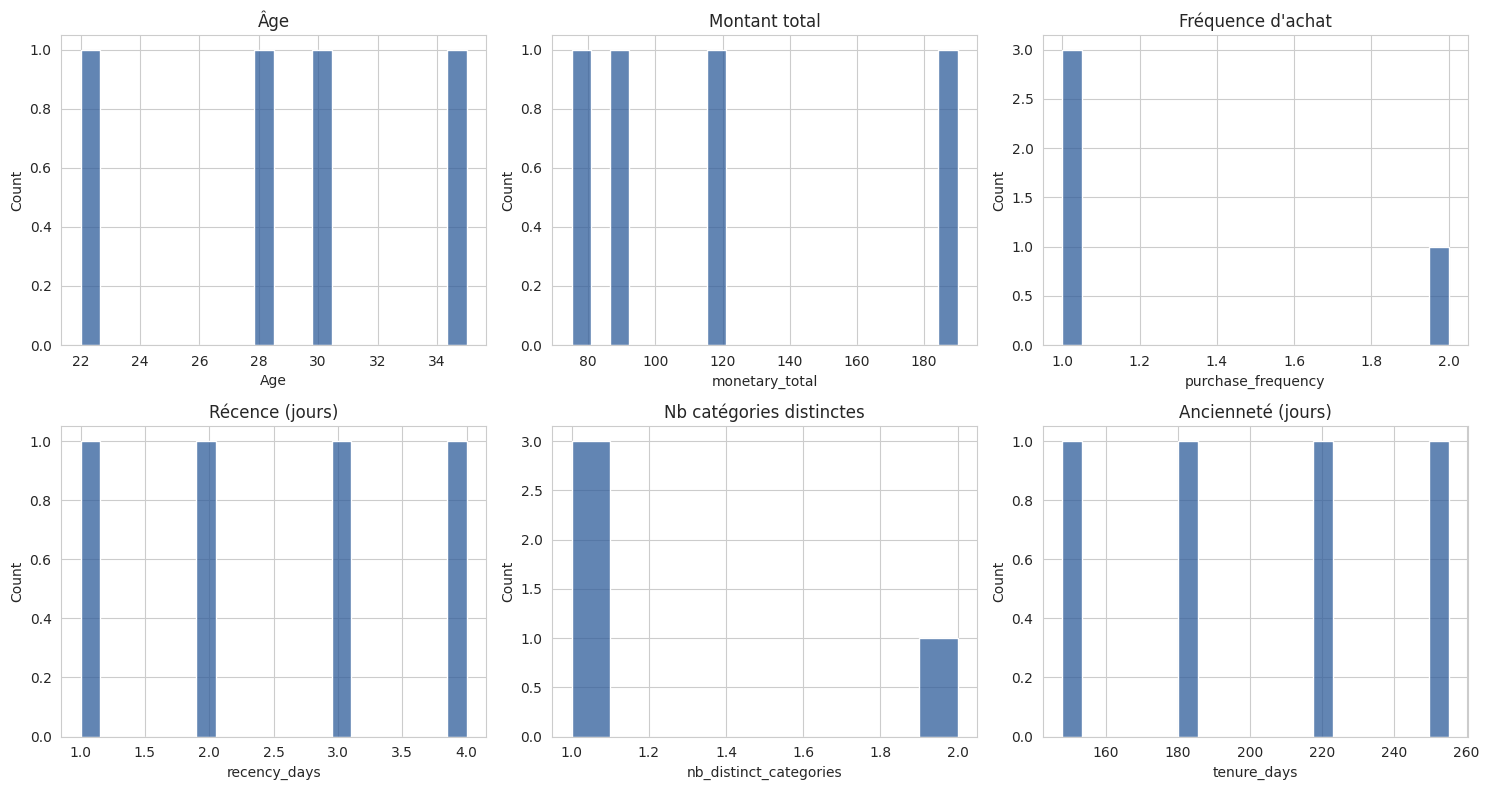

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sns.histplot(customer_features["Age"], bins=20, ax=axes[0,0], color="#2E5C9A").set_title("Âge")
sns.histplot(customer_features["monetary_total"], bins=20, ax=axes[0,1], color="#2E5C9A").set_title("Montant total")
sns.histplot(customer_features["purchase_frequency"], bins=20, ax=axes[0,2], color="#2E5C9A").set_title("Fréquence d'achat")
sns.histplot(customer_features["recency_days"], bins=20, ax=axes[1,0], color="#2E5C9A").set_title("Récence (jours)")
sns.histplot(customer_features["nb_distinct_categories"], bins=10, ax=axes[1,1], color="#2E5C9A").set_title("Nb catégories distinctes")
sns.histplot(customer_features["tenure_days"], bins=20, ax=axes[1,2], color="#2E5C9A").set_title("Ancienneté (jours)")
plt.tight_layout()
plt.show()

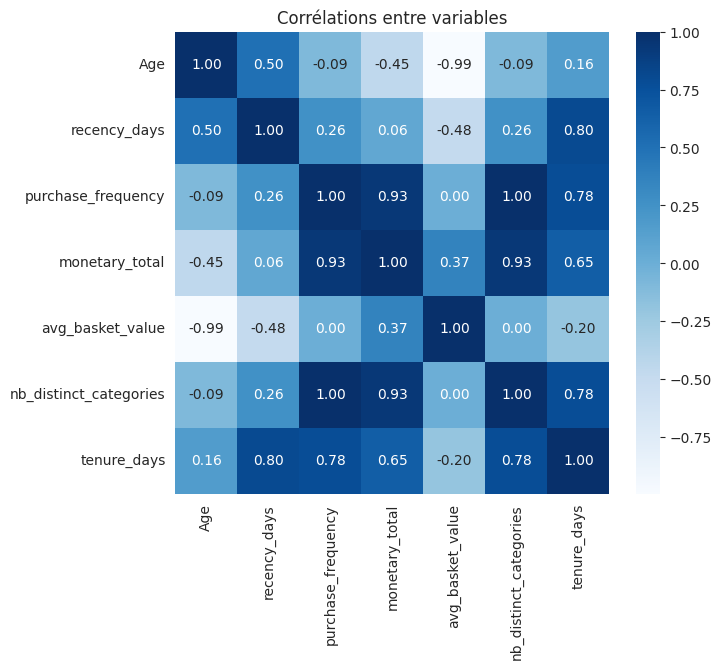

In [25]:
num_cols = [
    "Age", 
    "recency_days", 
    "purchase_frequency", 
    "monetary_total",
    "avg_basket_value", 
    "nb_distinct_categories", 
    "tenure_days"
    ]


plt.figure(figsize=(7, 6))
sns.heatmap(customer_features[num_cols].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Corrélations entre variables")
plt.show()

## 6. Prétraitement : standardisation

Variables numériques retenues pour le clustering

In [26]:
features = ["Age", "recency_days", "purchase_frequency", "monetary_total",
            "avg_basket_value", "nb_distinct_categories", "tenure_days"]

X = customer_features[features].copy()
X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)
X_scaled.describe().round(2)


,Age,recency_days,purchase_frequency,monetary_total,avg_basket_value,nb_distinct_categories,tenure_days
count,4.00,4.00,4.00,4.00,4.00,4.00,4.00
mean,-0.00,0.00,-0.00,0.00,0.00,-0.00,0.00
std,1.15,1.15,1.15,1.15,1.15,1.15,1.15
min,-1.45,-1.34,-0.58,-0.99,-1.23,-0.58,-1.34
25%,-0.48,-0.67,-0.58,-0.74,-0.54,-0.58,-0.67
50%,0.05,0.00,-0.58,-0.31,-0.15,-0.58,0.00
75%,0.54,0.67,0.00,0.42,0.39,0.00,0.67
max,1.34,1.34,1.73,1.61,1.54,1.73,1.34


## 7. Réduction de dimension (PCA)

Sert à visualiser les clients en 2D et à vérifier la variance expliquée par les variables choisies

Variance expliquée : [0.53066394 0.37239347]
Variance totale expliquée : 0.903


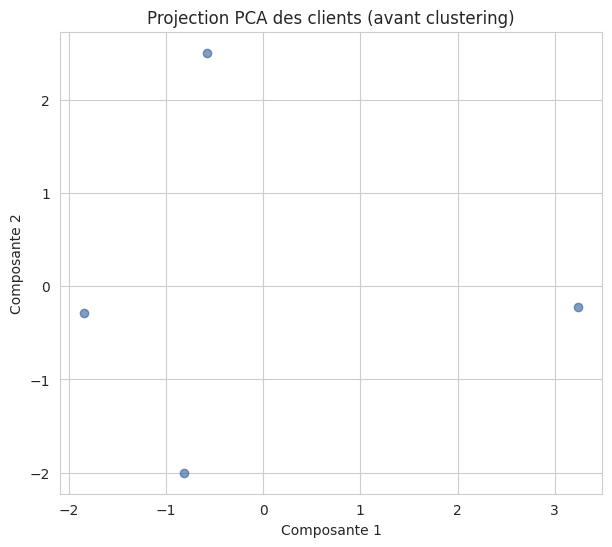

In [27]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Variance expliquée :", pca.explained_variance_ratio_)
print("Variance totale expliquée :", pca.explained_variance_ratio_.sum().round(3))

plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, color="#2E5C9A")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.title("Projection PCA des clients (avant clustering)")
plt.show()

In [28]:
# Contribution de chaque variable aux 2 composantes (utile pour interpréter les axes)
loadings = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2"], index=features)
loadings.round(3)

,PC1,PC2
Age,-0.041,0.597
recency_days,0.236,0.436
purchase_frequency,0.503,-0.048
monetary_total,0.469,-0.259
avg_basket_value,0.002,-0.585
nb_distinct_categories,0.503,-0.048
tenure_days,0.466,0.199


## 8. Choix du nombre optimal de clusters (k)

- **Méthode du coude** : où l'inertie cesse de baisser significativement
- **Score de silhouette** : qualité de séparation des clusters (proche de 1 = bon)


Nombre de clients disponibles pour le clustering : 4


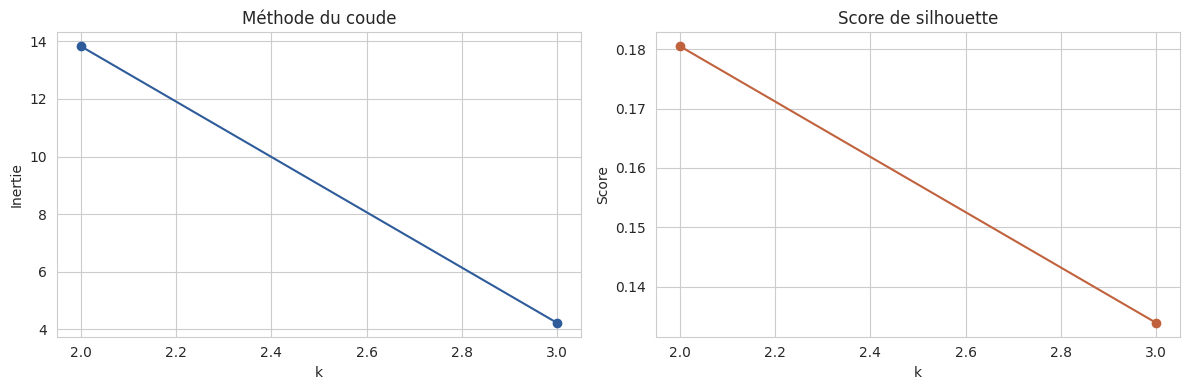

k=2 -> silhouette=0.181
k=3 -> silhouette=0.134

Attention : seulement 4 clients disponibles. Les scores ci-dessus restent calculables mathématiquement mais ne sont pas fiables statistiquement sur un si petit échantillon — à interpréter avec prudence, voire à ignorer si le volume réel reste aussi faible.


In [29]:
n_samples = X_scaled.shape[0]
print("Nombre de clients disponibles pour le clustering :", n_samples)

# k valide uniquement entre 2 et n_samples - 1
max_valid_k = n_samples - 1
k_range = range(2, min(9, max_valid_k + 1))



if max_valid_k < 2:
    print("\nVolume de données insuffisant pour un clustering statistique fiable "
          f"({n_samples} client(s) seulement). Le K-means nécessite idéalement plusieurs "
          "dizaines de clients pour produire des segments interprétables.")
    inertias, silhouettes = [], []
else:
    inertias = []
    silhouettes = []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_scaled, labels))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(list(k_range), inertias, marker="o", color="#2E5C9A")
    axes[0].set_title("Méthode du coude")
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("Inertie")

    axes[1].plot(list(k_range), silhouettes, marker="o", color="#C0623D")
    axes[1].set_title("Score de silhouette")
    axes[1].set_xlabel("k")
    axes[1].set_ylabel("Score")
    plt.tight_layout()
    plt.show()

    for k, s in zip(k_range, silhouettes):
        print(f"k={k} -> silhouette={s:.3f}")

    if n_samples < 20:
        print(f"\nAttention : seulement {n_samples} clients disponibles. Les scores ci-dessus "
              "restent calculables mathématiquement mais ne sont pas fiables statistiquement "
              "sur un si petit échantillon — à interpréter avec prudence, voire à ignorer si "
              "le volume réel reste aussi faible.")


**Lecture attendue :** ce dataset simulé est construit autour de 4 profils, le score de
silhouette devrait donc être maximal (ou proche) autour de **k = 4**. Retiens le k qui offre le
meilleur compromis coude/silhouette ET qui reste interprétable d'un point de vue métier.

## 9. Application du K-means avec le k retenu

In [30]:
K_OPTIMAL = 2

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
customer_features["cluster"] = kmeans.fit_predict(X_scaled)

customer_features["cluster"].value_counts().sort_index()


cluster
0    3
1    1
Name: count, dtype: int64

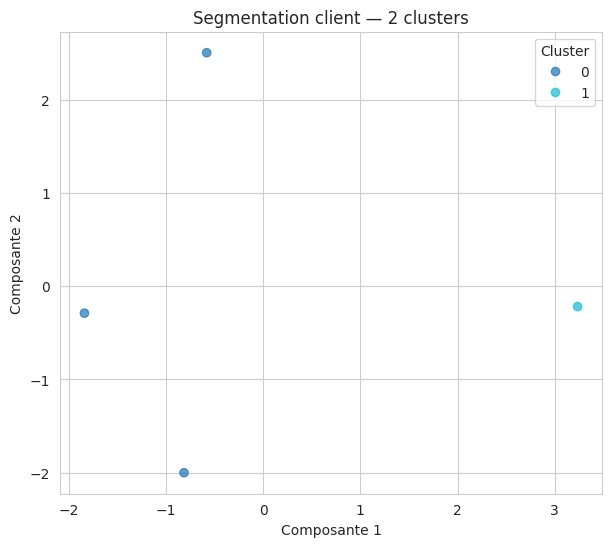

In [31]:
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=customer_features["cluster"], cmap="tab10", alpha=0.7)
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.title(f"Segmentation client — {K_OPTIMAL} clusters")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()


## 10. Validation du clustering pour une donnée de simulation


In [32]:
if "_segment_reel_pour_validation" in df.columns:
    validation = df.groupby("Customer_ID")["_segment_reel_pour_validation"].first()
    check = customer_features.merge(validation, on="Customer_ID")
    display(pd.crosstab(check["cluster"], check["_segment_reel_pour_validation"]))
else:
    print("Pas de colonne de validation disponible (dataset réel) — étape ignorée.")


Pas de colonne de validation disponible (dataset réel) — étape ignorée.


## 11. Profilage des segments

In [33]:
profile = customer_features.groupby("cluster")[features].mean().round(1)
profile["nb_clients"] = customer_features["cluster"].value_counts().sort_index()
profile


,Age,recency_days,purchase_frequency,monetary_total,avg_basket_value,nb_distinct_categories,tenure_days,nb_clients
cluster,,,,,,,,
0,29.0,2.3,1.0,95.0,95.0,1.0,183.7,3
1,28.0,3.0,2.0,190.0,95.0,2.0,255.0,1


In [34]:
# Préférences catégorielles dominantes par cluster
for c in sorted(customer_features["cluster"].unique()):
    sub = customer_features[customer_features["cluster"] == c]
    top_cat = sub["favorite_category"].mode()[0]
    top_channel = sub["preferred_channel"].mode()[0]
    top_location = sub["Location"].mode()[0]
    print(f"Cluster {c} — catégorie dominante: {top_cat} | canal dominant: {top_channel} | ville dominante: {top_location}")

Cluster 0 — catégorie dominante: Accessories | canal dominant: In-Store | ville dominante: Chicago
Cluster 1 — catégorie dominante: Clothing | canal dominant: Online | ville dominante: New York


### Rédaction de personas

| Cluster | Persona | Description |
|---|---|---|
| 0 | **Clients VIP** | Dépenses élevées, achats fréquents, récence faible — cœur de cible à fidéliser |
| 1 | **Occasionnels** | Faible fréquence, récence élevée — cible de réactivation |
| 2 | **Jeunes actifs** | Jeunes, achats fréquents, paniers moyens — cible marketing digital/mobile |
| 3 | **Fidèles économes** | Plus âgés, fréquence correcte, panier modéré — cible fidélité |

*(à remplacer par tes vraies observations une fois le clustering exécuté sur les données réelles)*

## 12. Export des résultats pour le reste de l'équipe



In [35]:
output = customer_features.drop(columns=["ecart_total_spent"], errors="ignore")
output.to_csv("../data/processed/segments_clients.csv", index=False)
print("Export terminé :", output.shape)
output.head()


Export terminé : (4, 20)


,Customer_ID,Name,Age,Gender,Location,Join_Date,Total_Spent,last_purchase_date,purchase_frequency,monetary_total,total_quantity,favorite_category,favorite_brand,preferred_channel,nb_distinct_categories,recency_days,avg_basket_value,avg_quantity_per_purchase,tenure_days,cluster
0,2001,Alice,28,Female,New York,2022-05-10,500.0,2023-01-17,2,190.0,5,Clothing,Brand A,Online,2,3,95.0,2.5,255,1
1,2002,Bob,35,Male,Los Angeles,2022-06-15,750.0,2023-01-16,1,75.0,1,Clothing,Brand B,In-Store,1,4,75.0,1.0,219,0
2,2003,Charlie,22,Male,Chicago,2022-07-20,300.0,2023-01-18,1,120.0,1,Outerwear,Brand D,In-Store,1,2,120.0,1.0,184,0
3,2004,Diana,30,Female,Houston,2022-08-25,600.0,2023-01-19,1,90.0,2,Accessories,Brand E,Online,1,1,90.0,2.0,148,0
